In [ ]:
import numpy as np
import sympy as sp
import pandas as pd

def solve_beam(l1, l2, q1, q2):
    l=l1+l2 #total length
    Mx=sp.symbols('Mx') #create symbol Mx

    #calculate Mx
    Mx=sp.solveset(Mx*l1/3+q1*l1**3/24+Mx*l2/3+q2*l2**3/24,Mx).args[0]

    #solve equilibrium equations
    Va, Vb1, Vb2, Vc=sp.symbols('Va Vb1 Vb2 Vc')
    Va, Vb1=sp.linsolve([Va+Vb1-q1*l1, Vb1*l1+Mx-(q1*l1**2)/2],
                        (Va, Vb1)).args[0]
    Vc, Vb2=sp.linsolve([Vb2+Vc-q2*l2, Vb2*12+Mx-(q2*l2**2)/2],
                       (Vc, Vb2)).args[0]
    Vb=Vb1+Vb2

    x1=np.arange(0, l1+0.1, 0.1) #create axis x1
    x2=np.arange(0, l2+0.1, 0.1) #cretae axis x2

    beam1=pd.DataFrame({"x":x1}) #create a dataframe for the first span
    beam2=pd.DataFrame({"x":x2}) #create a dataframe for the second span
    
    beam1["M"]=Va*beam1.x-(q1*beam1.x**2)/2 # calculate M and store it
    beam2["M"]=Mx-(q2*beam2.x**2)/2+Vb2*beam2.x # calculate M and store it

    beam1["V"]=Va-q1*beam1.x # calculate V and store it
    beam2["V"]=Vb2-q2*beam2.x # calculate V and store it

    beam2.x=beam2.x+l1 # re-assign x for the second span

    beam=pd.concat([beam1, beam2]) # concatenate the two dataframes

    return(beam) # return the result

header=pd.MultiIndex.from_tuples([
            ("combo 1", "M"), 
            ("combo 1", "V"),
            ("combo 2", "M"), 
            ("combo 2", "V")
            ])
combos = pd.DataFrame({
      "x": solve_beam(4, 5, 4.5, 3.2)["x"]})

result1 = solve_beam(4, 5, 4.5, 3.2)
result2 = solve_beam(4, 5, 3.2, 4.5)

combos[("combo 1", "M")] = result1["M"].to_numpy()
combos[("combo 1", "V")] = result1["V"].to_numpy()

combos[("combo 2", "M")] = result2["M"].to_numpy()
combos[("combo 2", "V")] = result2["V"].to_numpy()

cols = ["x"] + [col for col in combos.columns if col != "x"]
combos = combos[cols]

combos=combos.astype("float")
combos.head()

,x,"(combo 1, M)","(combo 1, V)","(combo 2, M)","(combo 2, V)"
0,0.0,0.000000,6.611111,0.000000,3.735764
1,0.1,0.638611,6.161111,0.357576,3.415764
2,0.2,1.232222,5.711111,0.683153,3.095764
3,0.3,1.780833,5.261111,0.976729,2.775764
4,0.4,2.284444,4.811111,1.238306,2.455764


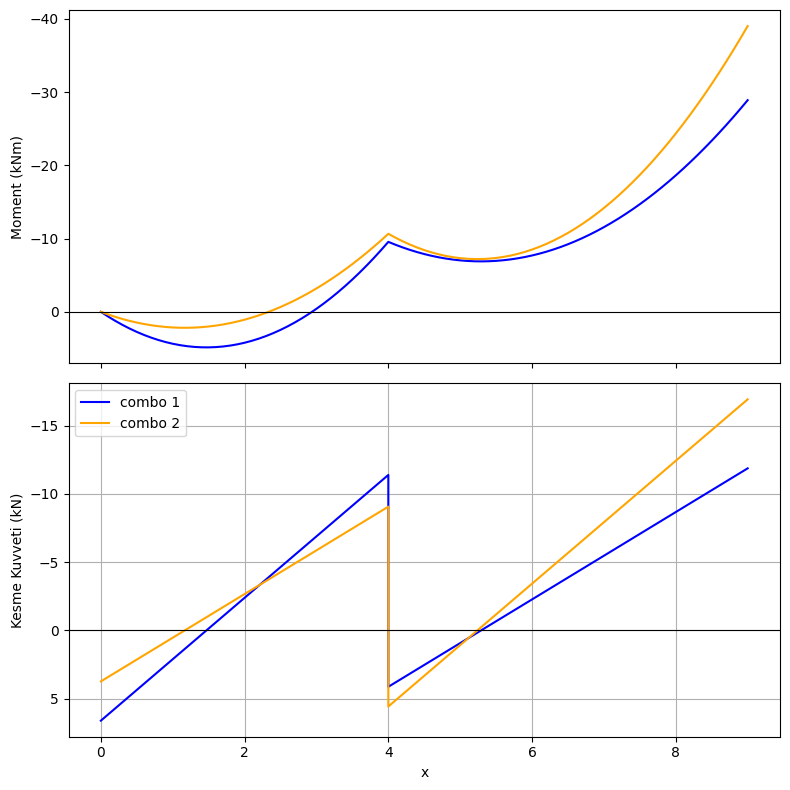

In [6]:
import matplotlib.pyplot as plt

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(8,8),
sharex = True)

# Moment diyagramı
ax1.plot(combos["x"], combos[("combo 1", "M")], label="combo 1", color="blue")
ax1.plot(combos["x"], combos[("combo 2", "M")], label="combo 2", color="orange")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.invert_yaxis() 
ax1.set_ylabel("Moment (kNm)")

# Kesme Kuvveti diyagramı
ax2.plot(combos["x"], combos[("combo 1", "V")], label="combo 1", color="blue")
ax2.plot(combos["x"], combos[("combo 2", "V")], label="combo 2", color="orange")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.invert_yaxis()  # Invert the y-axis for shear force diagram
ax2.set_xlabel("x")
ax2.set_ylabel("Kesme Kuvveti (kN)")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()